# Deep Neural Network Approximation of the Black-Scholes Pricing Surface
### M2R Group 51 — Week 3 | Justin

---

## 1. Introduction and Motivation

The Black-Scholes-Merton (BSM) model provides a closed-form solution for the price of a European call option under the assumptions of log-normally distributed asset returns and constant volatility. For a European call, the price is given by:

$$C(S, K, T, r, \sigma) = S \Phi(d_1) - K e^{-rT} \Phi(d_2)$$

where
$$d_1 = \frac{\ln(S/K) + (r + \frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

and $\Phi(\cdot)$ is the standard normal CDF.

Although BSM has an analytical solution, it serves as the ideal benchmark for validating a neural network approximation approach. More complex models — such as Heston stochastic volatility or SABR — do **not** admit closed-form solutions and require expensive Monte Carlo or PDE-based numerical solvers. A trained DNN can price options in microseconds, making it an attractive surrogate model in calibration routines that require millions of evaluations.

**This notebook trains a feedforward Deep Neural Network (DNN) to learn the Black-Scholes pricing map $f: (S, K, T, r, \sigma) \mapsto C$, benchmarks its accuracy, and quantifies the computational speedup it delivers.**

---
## 2. Imports and Environment Setup

In [5]:
import sys
import os
import time
import warnings
warnings.filterwarnings('ignore')

# Project imports
sys.path.append('../../')
from src.pricing.models import bsm_european

# Numerical / scientific
import numpy as np
import pandas as pd

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.8.0


---
## 3. Data Generation — Analytical Ground Truth

Because the BSM formula is exact, we generate training data with **zero variance**: every label $y_i = C(S_i, K_i, T_i, r_i, \sigma_i)$ is computed deterministically. This is in deliberate contrast to Monte Carlo estimates, which carry sampling noise proportional to $1/\sqrt{N_{\text{paths}}}$.

We draw the 500,000 parameter combinations using **uniform random sampling** across a realistic 5-dimensional financial parameter space.

### Parameter Ranges

| Parameter | Symbol | Range |
|---|---|---|
| Spot price | $S$ | [50, 200] |
| Strike price | $K$ | [50, 200] |
| Time to expiry | $T$ | [0.05, 3.0] (years) |
| Risk-free rate | $r$ | [0.0, 0.10] |
| Volatility | $\sigma$ | [0.05, 0.80] |


In [5]:
N_SAMPLES = 500_000

# Parameter bounds: [S, K, T, r, sigma]
LOWER = np.array([50.0,  50.0,  0.05, 0.00, 0.05])
UPPER = np.array([200.0, 200.0, 3.00, 0.10, 0.80])

print(f'Generating {N_SAMPLES:,} samples via uniform random sampling ...')
t0 = time.time()

rng    = np.random.default_rng(seed=SEED)
params = rng.uniform(low=LOWER, high=UPPER, size=(N_SAMPLES, 5))

S     = params[:, 0]
K     = params[:, 1]
T     = params[:, 2]
r     = params[:, 3]
sigma = params[:, 4]

# Compute analytical BSM prices
prices = np.array([bsm_european(S[i], K[i], T[i], r[i], sigma[i]) for i in range(N_SAMPLES)])

print(f'  Done in {time.time()-t0:.1f}s')
print(f'  Price range: [{prices.min():.4f}, {prices.max():.4f}]')
print(f'  NaN count  : {np.isnan(prices).sum()}')


Generating 500,000 samples via uniform random sampling ...
  Done in 27.3s
  Price range: [0.0000, 164.7645]
  NaN count  : 0


In [6]:
df = pd.DataFrame({'S': S, 'K': K, 'T': T, 'r': r, 'sigma': sigma, 'price': prices})

# Drop degenerate near-zero prices from extreme OTM / low-T combinations
df = df[df['price'] > 1e-6].reset_index(drop=True)
print(f'Clean dataset size: {len(df):,} rows')
df.describe().round(4)

Clean dataset size: 485,035 rows


,S,K,T,r,sigma,price
count,485035.0000,485035.0000,485035.0000,485035.0000,485035.0000,485035.0000
mean,126.5179,123.9139,1.5470,0.0501,0.4334,40.7512
std,42.8770,43.1965,0.8444,0.0289,0.2132,36.4976
min,50.0004,50.0006,0.0500,0.0000,0.0500,0.0000
25%,89.8719,86.4188,0.8225,0.0251,0.2516,8.7864
50%,127.1153,123.3792,1.5534,0.0501,0.4346,31.5685
75%,163.5847,161.1415,2.2786,0.0751,0.6179,65.3064
max,200.0000,199.9981,3.0000,0.1000,0.8000,164.7645


---
## 4. Preprocessing

Neural networks are sensitive to the scale of their inputs. The raw features span very different ranges: $S, K \in [50, 200]$ while $r \in [0, 0.10]$. Without normalisation, gradient descent update steps for large-scale features dominate, leading to slow and unstable convergence.

We apply **standardisation** (Z-score normalisation) via `StandardScaler`:

$$\hat{x}_j = \frac{x_j - \mu_j}{s_j}$$

where $\mu_j$ and $s_j$ are the mean and standard deviation of feature $j$ estimated on the **training set only** (to prevent data leakage).

In [7]:
FEATURE_COLS = ['S', 'K', 'T', 'r', 'sigma']
TARGET_COL   = 'price'

X = df[FEATURE_COLS].values.astype(np.float32)
y = df[TARGET_COL].values.astype(np.float32).reshape(-1, 1)

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

# Fit scaler on training data ONLY
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')
print(f'Feature means (train): {scaler.mean_.round(4)}')
print(f'Feature stds  (train): {scaler.scale_.round(4)}')

Training samples : 388,028
Test samples     : 97,007
Feature means (train): [1.264607e+02 1.239192e+02 1.546500e+00 5.010000e-02 4.332000e-01]
Feature stds  (train): [4.28748e+01 4.32077e+01 8.44500e-01 2.89000e-02 2.13300e-01]


---
## 5. DNN Architecture

Following the supervisor's guidance to keep the network **small and manageable**, we use:

- **Hidden layers**: 2
- **Neurons per layer**: 20
- **Activation**: ReLU, $\ell(z) = \max(z, 0)$. This non-polynomial, continuous function is the minimum requirement for the network to be a universal approximator (Leshno et al. 1993, cited in Davey & Zheng 2022).
- **Output**: 1 linear neuron — no activation, so the output is unbounded real-valued.
- **Initialisation**: Kaiming (He) normal, which sets weight variances to $2/n_{\text{in}}$ to compensate for ReLU halving the variance.

The forward pass for a network with $L = 2$ hidden layers is:
$$z_1 = A_1 x + b_1, \quad \tilde{z}_1 = \ell(z_1)$$
$$z_2 = A_2 \tilde{z}_1 + b_2, \quad \tilde{z}_2 = \ell(z_2)$$
$$\hat{C} = h(x) = A_3 \tilde{z}_2 + b_3$$

where $A_1 \in \mathbb{R}^{20 \times 5}$, $A_2 \in \mathbb{R}^{20 \times 20}$, $A_3 \in \mathbb{R}^{1 \times 20}$, and all $b_j$ are bias vectors of matching dimension.


In [8]:
class OptionPricingDNN(nn.Module):
    """
    Small feedforward DNN for Black-Scholes call option price regression.
    Follows supervisor guidance: 1-2 hidden layers, 10-20 neurons each.

    Default architecture
    --------------------
    Input(5) -> FC(20)->ReLU -> FC(20)->ReLU -> FC(1)
    """

    def __init__(self, input_dim: int = 5, hidden_dims: list = None):
        super(OptionPricingDNN, self).__init__()

        if hidden_dims is None:
            hidden_dims = [20, 20]   # 2 hidden layers, 20 neurons each

        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.ReLU())
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))

        self.network = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
                nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


model = OptionPricingDNN().to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal trainable parameters: {total_params:,}')
print('\nNote: small network per supervisor guidance (2 hidden layers x 20 neurons).')


OptionPricingDNN(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=1, bias=True)
  )
)

Total trainable parameters: 561

Note: small network per supervisor guidance (2 hidden layers x 20 neurons).


---
## 6. Training

### Loss Function — Mean Squared Error

$$\mathcal{L}(\theta) = \frac{1}{N} \sum_{i=1}^{N} \left( \hat{C}_i - C_i \right)^2$$

MSE heavily penalises large errors, encouraging the network to accurately price options across the full surface rather than sacrificing accuracy on tail cases.

### Optimiser — Adam

Adam (Kingma & Ba, 2015) combines momentum and adaptive per-parameter learning rates:

$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

where $\hat{m}_t$ and $\hat{v}_t$ are bias-corrected first and second moment estimates of the gradient. Adam converges faster than vanilla SGD on smooth financial surfaces.

A **ReduceLROnPlateau** scheduler halves the learning rate when validation loss plateaus for 5 consecutive epochs.

In [ ]:
BATCH_SIZE    = 4096
N_EPOCHS      = 60
LEARNING_RATE = 1e-3
VAL_SPLIT     = 0.10

X_tr = torch.tensor(X_train_sc, dtype=torch.float32)
y_tr = torch.tensor(y_train,    dtype=torch.float32)
X_te = torch.tensor(X_test_sc,  dtype=torch.float32)
y_te = torch.tensor(y_test,     dtype=torch.float32)

n_val   = int(VAL_SPLIT * len(X_tr))
n_train = len(X_tr) - n_val

train_ds = TensorDataset(X_tr[:n_train], y_tr[:n_train])
val_ds   = TensorDataset(X_tr[n_train:], y_tr[n_train:])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print(f'Training samples  : {n_train:,}')
print(f'Validation samples: {n_val:,}')
print(f'Batch size        : {BATCH_SIZE}')
print(f'Epochs            : {N_EPOCHS}')
print(f'Batches / epoch   : {len(train_loader)}')

Training samples  : 349,226
Validation samples: 38,802
Batch size        : 4096
Epochs            : 60
Batches / epoch   : 86


In [26]:
def run_epoch(loader, model, criterion, optimizer, train: bool):
    """Run one full epoch. Returns mean MSE loss over batches."""
    model.train(train)
    total_loss = 0.0
    with torch.set_grad_enabled(train):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
    return total_loss / len(loader)

In [ ]:
train_losses, val_losses = [], []
best_val_loss    = float('inf')
best_model_state = None

print(f'{"Epoch":>6}  {"Train MSE":>12}  {"Val MSE":>12}  {"LR":>10}')
print('-' * 50)

t_start = time.time()

for epoch in range(1, N_EPOCHS + 1):
    tr_loss  = run_epoch(train_loader, model, criterion, optimizer, train=True)
    val_loss = run_epoch(val_loader,   model, criterion, optimizer, train=False)

    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 5 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'{epoch:>6}  {tr_loss:>12.6f}  {val_loss:>12.6f}  {lr_now:>10.2e}')

print(f'\nTraining complete in {time.time()-t_start:.1f}s  |  Best val MSE: {best_val_loss:.6f}')

model.load_state_dict(best_model_state)
model.to(DEVICE)
print('Best model weights restored.')

 Epoch     Train MSE       Val MSE          LR
--------------------------------------------------


NameError: name 'model' is not defined

---
## 7. Evaluation

### 7.1 Loss Curves

A consistent, gap-free decrease in both training and validation loss confirms the network is learning the BSM surface without overfitting.

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

epochs_range = range(1, N_EPOCHS + 1)
ax.plot(epochs_range, train_losses, label='Training MSE',   color='steelblue', linewidth=2)
ax.plot(epochs_range, val_losses,   label='Validation MSE', color='tomato',    linewidth=2, linestyle='--')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('Training and Validation Loss — DNN Black-Scholes Approximation', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(False)

plt.tight_layout()
plt.savefig('/Users/JustinJu/Desktop/M2R/Option_Pricing_with_Stochastic_Volatility_Model_M2R_Group_51/week_3/Justin/LaTeX/M2R_Justin_Part/figures/loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: loss_curve.png')


### 7.2 Out-of-Sample Error Metrics

We evaluate on the held-out 20% test set using:

- **RMSE** $= \sqrt{\frac{1}{N}\sum_i(\hat{C}_i - C_i)^2}$ — in the same units as the option price; penalises large errors quadratically.
- **MAE** $= \frac{1}{N}\sum_i |\hat{C}_i - C_i|$ — robust to outliers; gives the typical absolute error.

In [12]:
model.eval()

with torch.no_grad():
    y_pred_tensor = model(X_te.to(DEVICE)).cpu().numpy()

y_true = y_test.flatten()
y_pred = y_pred_tensor.flatten()

rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
mae     = mean_absolute_error(y_true, y_pred)
rel_err = np.abs(y_pred - y_true) / (np.abs(y_true) + 1e-8)

print('=' * 45)
print('  Out-of-Sample Test Set Metrics')
print('=' * 45)
print(f'  RMSE                : {rmse:.6f}')
print(f'  MAE                 : {mae:.6f}')
print(f'  Mean Relative Error : {rel_err.mean()*100:.4f}%')
print(f'  Median Rel. Error   : {np.median(rel_err)*100:.4f}%')
print(f'  Max Absolute Error  : {np.abs(y_pred - y_true).max():.6f}')
print('=' * 45)

  Out-of-Sample Test Set Metrics
  RMSE                : 1.425581
  MAE                 : 1.076907
  Mean Relative Error : 187839.9048%
  Median Rel. Error   : 3.0365%
  Max Absolute Error  : 16.936390


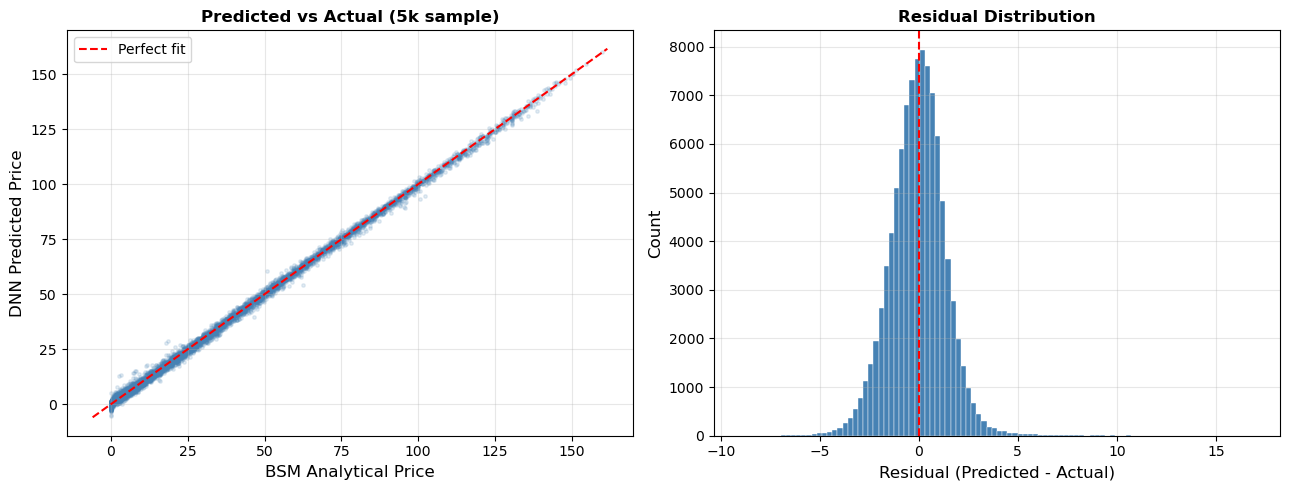

Saved: evaluation_plots.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

idx = np.random.choice(len(y_true), size=5000, replace=False)

ax = axes[0]
ax.scatter(y_true[idx], y_pred[idx], alpha=0.15, s=6, color='steelblue')
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('BSM Analytical Price', fontsize=12)
ax.set_ylabel('DNN Predicted Price',  fontsize=12)
ax.set_title('Predicted vs Actual (5k sample)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

ax = axes[1]
residuals = y_pred - y_true
ax.hist(residuals, bins=100, color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Residual (Predicted - Actual)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Residual Distribution', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/JustinJu/Desktop/M2R/Option_Pricing_with_Stochastic_Volatility_Model_M2R_Group_51/week_3/Justin/LaTeX/M2R_Justin_Part/figures/evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: evaluation_plots.png')

---
## 8. Speed Benchmark — DNN vs Analytical BSM

One of the principal motivations for neural network surrogate models is inference speed. We benchmark pricing **100,000 options** using:

1. The analytical `bsm_european` function (sequential Python calls over a loop)
2. The trained DNN (single batched forward pass on CPU)

The DNN computes all prices simultaneously via a single matrix multiplication chain, whereas the Python loop incurs interpreter overhead per call.

In [ ]:
N_BENCH    = 100_000   # closed-form & DNN — both cheap enough per option
N_BENCH_MC = 2_000     # Monte Carlo is far slower per option, so price fewer
M_PATHS_BS = 10_000    # MC paths per option

from src.pricing.models import mc_european_gbm

rng = np.random.default_rng(seed=99)
bench_params = rng.uniform(low=LOWER, high=UPPER, size=(N_BENCH, 5)).astype(np.float32)

# Benchmark 1: Analytical BSM closed-form (Python loop)
t0 = time.perf_counter()
bsm_prices = np.array([
    bsm_european(bench_params[i,0], bench_params[i,1],
                 bench_params[i,2], bench_params[i,3], bench_params[i,4])
    for i in range(N_BENCH)
])
t_bsm = time.perf_counter() - t0

# Benchmark 2: Monte Carlo under GBM (Python loop, M_PATHS_BS paths/option)
t0 = time.perf_counter()
mc_prices = np.array([
    mc_european_gbm(bench_params[i,0], bench_params[i,1], bench_params[i,2],
                    bench_params[i,3], bench_params[i,4], M_PATHS_BS, seed=i)[0]
    for i in range(N_BENCH_MC)
])
t_mc = time.perf_counter() - t0

# Benchmark 3: DNN (single batched forward pass, CPU)
bench_scaled = scaler.transform(bench_params)
bench_tensor = torch.tensor(bench_scaled, dtype=torch.float32)

model_cpu = model.to('cpu')
model_cpu.eval()

# Warm-up (avoids one-time JIT overhead in timing)
with torch.no_grad():
    _ = model_cpu(bench_tensor[:100])

t0 = time.perf_counter()
with torch.no_grad():
    dnn_prices = model_cpu(bench_tensor).numpy().flatten()
t_dnn = time.perf_counter() - t0

# Compare on a like-for-like PER-OPTION basis, since N differs across methods
us_bsm = t_bsm / N_BENCH * 1e6
us_mc  = t_mc  / N_BENCH_MC * 1e6
us_dnn = t_dnn / N_BENCH * 1e6

print('=' * 65)
print(f'  Benchmark: Black-Scholes pricing — cost per option')
print('=' * 65)
print(f'  BSM closed-form (loop, N={N_BENCH:,})     : {us_bsm:9.2f} us/option')
print(f'  Monte Carlo (M={M_PATHS_BS:,}, N={N_BENCH_MC:,})    : {us_mc:9.2f} us/option')
print(f'  DNN forward pass (N={N_BENCH:,})          : {us_dnn:9.2f} us/option')
print('-' * 65)
print(f'  Speed-up DNN vs closed-form : {us_bsm/us_dnn:>8.1f}x')
print(f'  Speed-up DNN vs Monte Carlo : {us_mc/us_dnn:>8.1f}x')
print('=' * 65)

corr = np.corrcoef(bsm_prices, dnn_prices)[0, 1]
print(f'  Pearson correlation (DNN vs BSM): {corr:.8f}')


In [ ]:
# Bar-chart visualisation of the benchmark removed — with three methods
# spanning several orders of magnitude (us vs ms per option) a bar chart adds
# little beyond the printed table above, so we report the numbers directly
# in the table in the write-up instead.


---
## 9. Pricing Surface Visualisation

To provide geometric intuition, we fix $T = 1.0$, $r = 0.05$, $\sigma = 0.20$ and plot the DNN-predicted call price surface over a $(S, K)$ grid alongside the exact BSM surface and the pointwise absolute error.

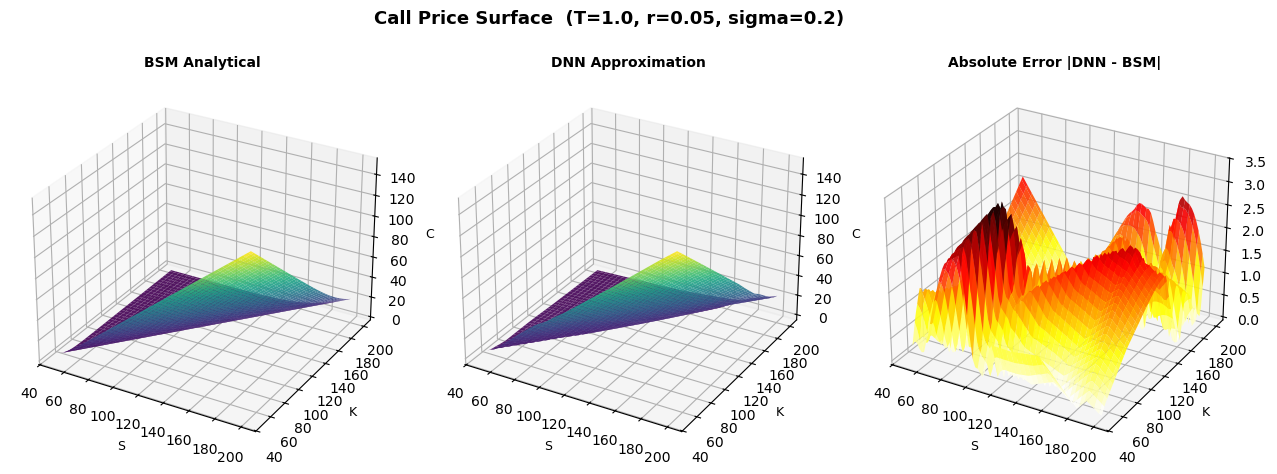

Saved: pricing_surface.png


In [25]:
T_fix, r_fix, sig_fix = 1.0, 0.05, 0.20
N_GRID = 80

S_grid = np.linspace(50, 200, N_GRID)
K_grid = np.linspace(50, 200, N_GRID)
SS, KK = np.meshgrid(S_grid, K_grid)

flat = np.column_stack([
    SS.ravel(), KK.ravel(),
    np.full(N_GRID**2, T_fix),
    np.full(N_GRID**2, r_fix),
    np.full(N_GRID**2, sig_fix)
]).astype(np.float32)

flat_sc = scaler.transform(flat)
flat_t  = torch.tensor(flat_sc, dtype=torch.float32)

with torch.no_grad():
    dnn_surface = model_cpu(flat_t).numpy().reshape(N_GRID, N_GRID)

bsm_surface = np.array([
    bsm_european(flat[i,0], flat[i,1], T_fix, r_fix, sig_fix)
    for i in range(N_GRID**2)
]).reshape(N_GRID, N_GRID)

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.1)

titles = ['BSM Analytical', 'DNN Approximation', 'Absolute Error |DNN - BSM|']
data   = [bsm_surface, dnn_surface, np.abs(bsm_surface - dnn_surface)]
cmaps  = ['viridis', 'viridis', 'hot_r']

for j, (surf, title, cmap) in enumerate(zip(data, titles, cmaps)):
    ax = fig.add_subplot(gs[j], projection='3d')
    ax.plot_surface(SS, KK, surf, cmap=cmap, alpha=0.9, linewidth=0)
    ax.set_xlabel('S', fontsize=9)
    ax.set_ylabel('K', fontsize=9)
    ax.set_zlabel('C', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.view_init(elev=28, azim=-60)

fig.suptitle(f'Call Price Surface  (T={T_fix}, r={r_fix}, sigma={sig_fix})',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('/Users/JustinJu/Desktop/M2R/Option_Pricing_with_Stochastic_Volatility_Model_M2R_Group_51/week_3/Justin/LaTeX/M2R_Justin_Part/figures/pricing_surface.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pricing_surface.png')

---
## 10. Save the Trained Model

We persist both the network weights and the `StandardScaler` so the surrogate can be loaded and used without retraining.

In [17]:
import joblib

torch.save(model.state_dict(), 'dnn_bs_model.pt')
joblib.dump(scaler, 'feature_scaler.pkl')

print('Saved model  : dnn_bs_model.pt')
print('Saved scaler : feature_scaler.pkl')

# Load and sanity-check
loaded_model = OptionPricingDNN()
loaded_model.load_state_dict(torch.load('dnn_bs_model.pt', map_location='cpu'))
loaded_model.eval()

test_params = [[100.0, 100.0, 1.0, 0.05, 0.20]]
with torch.no_grad():
    inp     = torch.tensor(scaler.transform(test_params), dtype=torch.float32)
    dnn_val = loaded_model(inp).item()

bsm_val = bsm_european(100.0, 100.0, 1.0, 0.05, 0.20)

print(f'\nSanity check  S=100, K=100, T=1, r=5%, sigma=20%')
print(f'  BSM analytical : {bsm_val:.6f}')
print(f'  DNN loaded     : {dnn_val:.6f}')
print(f'  Absolute error : {abs(dnn_val - bsm_val):.6f}')

Saved model  : dnn_bs_model.pt
Saved scaler : feature_scaler.pkl

Sanity check  S=100, K=100, T=1, r=5%, sigma=20%
  BSM analytical : 10.450584
  DNN loaded     : 9.182979
  Absolute error : 1.267605


---

# Chapter 2: Extending to the Heston Stochastic Volatility Model

## 2.1 Why go beyond Black–Scholes?

The Black–Scholes–Merton (BSM) model used in Chapter 1 assumes volatility $\sigma$ is **constant** over the life of the option. Real markets contradict this: implied volatilities extracted from traded option prices vary with both strike and maturity, producing the well-known **"volatility smile / skew"**.

The **Heston model** (Heston, 1993) fixes this by letting the *variance* of the underlying itself evolve as a **random process** — i.e. "stochastic volatility", which is the actual subject of your M2R project. This chapter sketches how to repeat the full Chapter 1 pipeline (generate data → train DNN → evaluate → benchmark) for Heston instead of BSM.

> **This chapter is deliberately left as a guide + skeleton, not a finished implementation.** Filling in the `TODO` blocks is a great way to consolidate everything from Chapter 1 — and to produce genuinely your-own results for the write-up.

## 2.2 The Heston dynamics

Under the risk-neutral measure, the asset price $S_t$ and its instantaneous variance $v_t$ satisfy a *pair* of coupled stochastic differential equations (SDEs):

$$dS_t = r S_t \, dt + \sqrt{v_t}\, S_t \, dW_t^{S}$$
$$dv_t = \kappa(\theta - v_t)\, dt + \xi \sqrt{v_t}\, dW_t^{v}$$

with the two driving Brownian motions correlated:
$$dW_t^{S} \, dW_t^{v} = \rho \, dt$$

The variance equation is a **CIR (Cox–Ingersoll–Ross) process** — the same family used to model interest rates. It is mean-reverting (pulled back towards a long-run level $\theta$) and stays non-negative (almost surely positive, given mild conditions — see §2.3).

## 2.3 The five new parameters

On top of the familiar $(S, K, T, r)$, you now have **five extra parameters** describing the variance process:

| Symbol | Name | Meaning |
|---|---|---|
| $v_0$ | initial variance | the variance at $t=0$, i.e. "today's" $\sigma^2$ |
| $\kappa$ | mean-reversion speed | how quickly $v_t$ is pulled back towards $\theta$ |
| $\theta$ | long-run variance | the level $v_t$ reverts to over the long run |
| $\xi$ | vol-of-vol | how volatile the variance process itself is |
| $\rho$ | correlation | correlation between price shocks and variance shocks (empirically usually **negative** — the "leverage effect": prices fall ⇒ volatility spikes) |

Worth knowing: the **Feller condition** $2\kappa\theta > \xi^2$ guarantees $v_t$ never reaches zero. Calibrated market parameters often violate it in practice, and the numerical scheme in §2.4 handles that gracefully — so don't worry about strictly enforcing it when sampling parameters.

## 2.4 Step 1 — How do you get a "ground truth" Heston price?

This is the first big difference from Chapter 1. The BSM price has a clean **closed-form formula** (`bsm_european`) you can evaluate in microseconds. The Heston price has **no simple algebraic expression** once $v_t$ is random — $\mathbb{E}[\max(S_T - K, 0)]$ must be computed numerically. Two standard routes:

**Semi-closed-form via the characteristic function** *(faster once built, more advanced)*
Heston (1993) expressed the price as
$$C = S_0 P_1 - K e^{-rT} P_2$$
where $P_1, P_2$ come from numerically integrating (e.g. `scipy.integrate.quad`) an expression involving the *characteristic function* $\phi(u)$ of $\ln S_T$. Fast once implemented (milliseconds/price), but fiddly with complex numbers — search for the Carr–Madan or Lewis (2000) reformulations, which avoid the "branch-cut" numerical issues of the original Heston formula.

In [1]:
import sys
import os
import time
import warnings
warnings.filterwarnings('ignore')

# Project imports
sys.path.append('../../')
from src.pricing.models import heston_semi_analytic

# Numerical / scientific
import numpy as np
import pandas as pd

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')


Using device: cpu
PyTorch version: 2.8.0


## 2.5 Step 2 — Choosing the Heston parameter space

Exactly as Chapter 1 defined `LOWER` / `UPPER` for $(S, K, T, r, \sigma)$, you now need sensible sampling ranges for **nine** inputs: the original four $(S, K, T, r)$ plus the five Heston parameters $(v_0, \kappa, \theta, \xi, \rho)$.

A reasonable starting point (cross-check these against any calibration values discussed in lectures, or in the papers you've read, before finalising):

| Parameter | Suggested range | Notes |
|---|---|---|
| $S$ | $[50,\ 200]$ | same as Chapter 1 |
| $K$ | $[50,\ 200]$ | same as Chapter 1 |
| $T$ | $[0.05,\ 3.0]$ | same as Chapter 1 |
| $r$ | $[0.00,\ 0.10]$ | same as Chapter 1 |
| $v_0$ | $[0.01,\ 0.50]$ | so initial volatility $\sqrt{v_0}\in[0.1,\ 0.7]$ |
| $\kappa$ | $[0.1,\ 5.0]$ | mean-reversion speed |
| $\theta$ | $[0.01,\ 0.50]$ | long-run variance |
| $\xi$ | $[0.05,\ 1.0]$ | vol-of-vol |
| $\rho$ | $[-0.75,\ 0.75]$ | correlation — empirically usually negative |



In [11]:
import time
import numpy as np
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

# (Ensure heston_semi_analytic is imported from your models.py at the top of your notebook)

# Helper function to unpack the row array for joblib
def _heston_worker(row):
    return heston_semi_analytic(*row)

# column order (S, K, T, r, V0, kappa, theta, omega, rho)
LOWER_HESTON = np.array([50, 50, 0.05, 0.00, 0.01, 0.1, 0.01, 0.05, -0.75])
UPPER_HESTON = np.array([200, 200, 3.0, 0.10, 0.50, 5.0, 0.50, 1.0, 0.75])

# TIP: Test with 1,000 before running 500,000!
N_SAMPLES = 500_000
SEED = 42

print(f'Generating {N_SAMPLES:,} samples via uniform random sampling ...')
t0 = time.time()

rng = np.random.default_rng(seed=SEED)
params = rng.uniform(low=LOWER_HESTON, high=UPPER_HESTON, size=(N_SAMPLES, 9))

print("Calculating prices using all CPU cores via Joblib...")

# Joblib handles Jupyter notebook memory spaces seamlessly
# n_jobs=-1 tells it to use all available CPU cores
prices = Parallel(n_jobs=-1)(
    delayed(_heston_worker)(row) for row in tqdm(params, total=N_SAMPLES)
)

prices = np.array(prices)

print(f'\nDone in {time.time()-t0:.1f}s')
print(f'Price range: [{np.nanmin(prices):.4f}, {np.nanmax(prices):.4f}]')
print(f'NaN count  : {np.isnan(prices).sum()}')

# SAVE THE DATASET TO DISK SO YOU NEVER HAVE TO RUN THIS AGAIN
np.save('heston_params_500k.npy', params)
np.save('heston_prices_500k.npy', prices)
print("Dataset successfully saved to disk as .npy files.")

Generating 500,000 samples via uniform random sampling ...
Calculating prices using all CPU cores via Joblib...


  0%|          | 0/500000 [00:00<?, ?it/s]


Done in 662.1s
Price range: [-36.4446, 169.3469]
NaN count  : 0
Dataset successfully saved to disk as .npy files.


In [13]:
df = pd.DataFrame({'S': S, 'K': K, 'T': T, 'r': r, 'V0': V0, 'kappa': kappa, 'theta': theta, 'omega': omega, 'rho': rho, 'price': prices})

# Drop degenerate near-zero prices from extreme OTM / low-T combinations
df = df[df['price'] > 1e-6].reset_index(drop=True)
print(f'Clean dataset size: {len(df):,} rows')
df.describe().round(4)

Clean dataset size: 495,098 rows


,S,K,T,r,V0,kappa,theta,omega,rho,price
count,495098.0000,495098.0000,495098.0000,495098.0000,495098.0000,495098.0000,495098.0000,495098.0000,495098.0000,495098.0000
mean,125.4555,124.6969,1.5317,0.0501,0.2558,2.5452,0.2558,0.5239,0.0029,41.4014
std,43.1515,43.2117,0.8471,0.0289,0.1413,1.4137,0.1413,0.2740,0.4323,35.6869
min,50.0001,50.0006,0.0500,0.0000,0.0100,0.1000,0.0100,0.0500,-0.7500,0.0000
25%,88.2248,87.3799,0.7987,0.0250,0.1334,1.3177,0.1338,0.2872,-0.3708,10.6922
50%,125.5494,124.4391,1.5322,0.0501,0.2557,2.5444,0.2558,0.5230,0.0037,32.7306
75%,162.8406,162.1056,2.2646,0.0751,0.3782,3.7703,0.3783,0.7611,0.3770,64.9259
max,199.9999,199.9998,3.0000,0.1000,0.5000,5.0000,0.5000,1.0000,0.7500,169.3469


## 2.6 Step 3 — A DNN for the Heston surface

Good news: **no new architecture class is needed**. `OptionPricingDNN` from Chapter 1 already takes an `input_dim` argument — simply instantiate it with `input_dim=9`:

```python
model_heston = OptionPricingDNN(input_dim=9, hidden_dims=[20, 20]).to(DEVICE)
```

Two things worth thinking about / experimenting with:

  - **Is $[20, 20]$ still big enough?** The network must now learn a map from a *9-dimensional* input to a price — a substantially more complex surface than the 5-D BSM case. You may find a somewhat larger network (e.g. $[40, 40]$) is needed to reach comparable accuracy. This is a great experiment to report: does the parameter-count formula from Davey & Zheng, $\rho(p, q) = (L-1)\ell^2 + \ell(L + p + q) + q$, help you reason about *how much* bigger $\ell$ should grow as the input dimension $p$ grows?
  - **Preprocessing is identical in spirit but not in substance**: fit a *brand-new* `StandardScaler` on the 9 training-input columns (do **not** reuse the BSM scaler — these nine variables live on very different numerical scales), then reuse the same train / validation / test splitting logic and `TensorDataset` / `DataLoader` machinery.

In [23]:
# column order (S, K, T, r, V0, kappa, theta, omega, rho)

FEATURE_COLS = ['S', 'K', 'T', 'r', 'V0', 'kappa', 'theta', 'omega', 'rho']
TARGET_COL   = 'price'

X = df[FEATURE_COLS].values.astype(np.float32)
y = df[TARGET_COL].values.astype(np.float32).reshape(-1, 1)

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

# Fit scaler on training data ONLY
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')
print(f'Feature means (train): {scaler.mean_.round(4)}')
print(f'Feature stds  (train): {scaler.scale_.round(4)}')

# ===============Models==============
class OptionPricingDNN(nn.Module):
    """
    Small feedforward DNN for Black-Scholes call option price regression.
    Follows supervisor guidance: 1-2 hidden layers, 10-20 neurons each.

    Default architecture
    --------------------
    Input(5) -> FC(20)->ReLU -> FC(20)->ReLU -> FC(1)
    """

    def __init__(self, input_dim: int = 9, hidden_dims: list = None):
        super(OptionPricingDNN, self).__init__()

        if hidden_dims is None:
            hidden_dims = [40, 40]   # 2 hidden layers, 40 neurons each

        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.ReLU())
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))

        self.network = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
                nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


hs_model = OptionPricingDNN().to(DEVICE)

total_params = sum(p.numel() for p in hs_model.parameters() if p.requires_grad)
print(hs_model)
print(f'\nTotal trainable parameters: {total_params:,}')
print('\nNote: small network per supervisor guidance (2 hidden layers x 20 neurons).')

#===============BATCH================
BATCH_SIZE    = 4096
N_EPOCHS      = 60
LEARNING_RATE = 1e-3
VAL_SPLIT     = 0.10

X_tr = torch.tensor(X_train_sc, dtype=torch.float32)
y_tr = torch.tensor(y_train,    dtype=torch.float32)
X_te = torch.tensor(X_test_sc,  dtype=torch.float32)
y_te = torch.tensor(y_test,     dtype=torch.float32)

n_val   = int(VAL_SPLIT * len(X_tr))
n_train = len(X_tr) - n_val

train_ds = TensorDataset(X_tr[:n_train], y_tr[:n_train])
val_ds   = TensorDataset(X_tr[n_train:], y_tr[n_train:])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(hs_model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print(f'Training samples  : {n_train:,}')
print(f'Validation samples: {n_val:,}')
print(f'Batch size        : {BATCH_SIZE}')
print(f'Epochs            : {N_EPOCHS}')
print(f'Batches / epoch   : {len(train_loader)}')


Training samples : 396,078
Test samples     : 99,020
Feature means (train): [1.254750e+02 1.246573e+02 1.531200e+00 5.010000e-02 2.557000e-01
 2.546000e+00 2.558000e-01 5.241000e-01 3.400000e-03]
Feature stds  (train): [4.31644e+01 4.31999e+01 8.46700e-01 2.89000e-02 1.41400e-01 1.41300e+00
 1.41200e-01 2.74000e-01 4.32300e-01]
OptionPricingDNN(
  (network): Sequential(
    (0): Linear(in_features=9, out_features=40, bias=True)
    (1): ReLU()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): ReLU()
    (4): Linear(in_features=40, out_features=1, bias=True)
  )
)

Total trainable parameters: 2,081

Note: small network per supervisor guidance (2 hidden layers x 20 neurons).
Training samples  : 356,471
Validation samples: 39,607
Batch size        : 4096
Epochs            : 60
Batches / epoch   : 88


## 2.7 Step 4 — Training: reuse everything from Chapter 1

This is the easiest part of the whole chapter: **`run_epoch` and the training loop need no changes whatsoever**. They were written generically — they only take `loader`, `model`, `criterion`, `optimizer` as arguments — so you can call the exact same functions again, simply pointing them at the new Heston model and DataLoaders:

```python
for epoch in range(1, N_EPOCHS_HESTON + 1):
    tr_loss  = run_epoch(train_loader_heston, model_heston, criterion, optimizer_heston, train=True)
    val_loss = run_epoch(val_loader_heston,   model_heston, criterion, optimizer_heston, train=False)
    # ... record losses, scheduler_heston.step(val_loss), checkpoint best weights —
    #     identical structure to Chapter 1, just with the _heston variables.
```

This is a nice concrete illustration of *why* it pays to write training code generically in the first place: the very same machinery now trains a completely different surrogate model with zero modification.

In [27]:
train_losses, val_losses = [], []
best_val_loss    = float('inf')
best_model_state = None

print(f'{"Epoch":>6}  {"Train MSE":>12}  {"Val MSE":>12}  {"LR":>10}')
print('-' * 50)

t_start = time.time()

for epoch in range(1, N_EPOCHS + 1):
    tr_loss  = run_epoch(train_loader, hs_model, criterion, optimizer, train=True)
    val_loss = run_epoch(val_loader,   hs_model, criterion, optimizer, train=False)

    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_model_state = {k: v.cpu().clone() for k, v in hs_model.state_dict().items()}

    if epoch % 5 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'{epoch:>6}  {tr_loss:>12.6f}  {val_loss:>12.6f}  {lr_now:>10.2e}')

print(f'\nTraining complete in {time.time()-t_start:.1f}s  |  Best val MSE: {best_val_loss:.6f}')

hs_model.load_state_dict(best_model_state)
hs_model.to(DEVICE)
print('Best model weights restored.')

 Epoch     Train MSE       Val MSE          LR
--------------------------------------------------
     1   2516.570063   1914.578137    1.00e-03
     5     56.719185     48.291163    1.00e-03
    10     24.600976     23.306070    1.00e-03
    15     16.544334     15.783975    1.00e-03
    20     11.544000     10.990396    1.00e-03
    25      8.207824      7.853599    1.00e-03
    30      6.255528      6.046563    1.00e-03
    35      5.072941      4.943980    1.00e-03
    40      4.212736      4.131792    1.00e-03
    45      3.612567      3.588896    1.00e-03
    50      3.154169      3.100400    1.00e-03
    55      2.789159      2.750814    1.00e-03
    60      2.492213      2.452140    1.00e-03

Training complete in 140.0s  |  Best val MSE: 2.452140
Best model weights restored.


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

epochs_range = range(1, N_EPOCHS + 1)
ax.plot(epochs_range, train_losses, label='Training MSE',   color='steelblue', linewidth=2)
ax.plot(epochs_range, val_losses,   label='Validation MSE', color='tomato',    linewidth=2, linestyle='--')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('Training and Validation Loss — DNN Heston Approximation', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(False)

plt.tight_layout()
plt.savefig('/Users/JustinJu/Desktop/M2R/Option_Pricing_with_Stochastic_Volatility_Model_M2R_Group_51/week_3/Justin/LaTeX/M2R_Justin_Part/figures/heston_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: heston_loss_curve.png')


## 2.8 Step 5 — Evaluation, and why the speed benchmark gets *much* more dramatic

Reuse the RMSE / MAE / relative-error evaluation block from Chapter 1 unchanged — just point it at `model_heston` and the Heston test set (same metrics, same caveats about relative error blowing up near zero-priced options apply here too).

The **speed benchmark** is where this chapter really earns its keep. In Chapter 1 you compared:

  - DNN inference (a few matrix multiplications)  **vs**
  - the closed-form BSM formula (already very fast — a handful of `norm.cdf` calls)

For Heston the comparison becomes:

  - DNN inference — **exactly the same cost as before** (the trained network has no idea, and does not care, how its training labels were produced)  **vs**
  - Monte-Carlo (or characteristic-function) Heston pricing — plausibly **milliseconds to seconds per price**

So where the BSM-trained DNN was perhaps "a few times faster" than the analytical formula, the Heston-trained DNN could realistically be **thousands of times faster** than generating a single ground-truth Heston price from scratch. This is the central practical argument for using DNN surrogates in stochastic-volatility pricing — make sure to actually measure and report the real numbers you observe, following the same `time.time()`-based pattern as the Chapter 1 benchmark cell.

In [ ]:
hs_model.eval()

with torch.no_grad():
    y_pred_tensor = hs_model(X_te.to(DEVICE)).cpu().numpy()

y_true = y_test.flatten()
y_pred = y_pred_tensor.flatten()

rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
mae     = mean_absolute_error(y_true, y_pred)
rel_err = np.abs(y_pred - y_true) / (np.abs(y_true) + 1e-8)

print('=' * 45)
print('  Heston DNN — Out-of-Sample Test Set Metrics')
print('=' * 45)
print(f'  RMSE                : {rmse:.6f}')
print(f'  MAE                 : {mae:.6f}')
print(f'  Mean Relative Error : {rel_err.mean()*100:.4f}%')
print(f'  Median Rel. Error   : {np.median(rel_err)*100:.4f}%')
print(f'  Max Absolute Error  : {np.abs(y_pred - y_true).max():.6f}')
print('=' * 45)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

idx = np.random.choice(len(y_true), size=5000, replace=False)

ax = axes[0]
ax.scatter(y_true[idx], y_pred[idx], alpha=0.15, s=6, color='steelblue')
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Heston Semi-Analytical Price', fontsize=12)
ax.set_ylabel('DNN Predicted Price',          fontsize=12)
ax.set_title('Predicted vs Actual (5k sample)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

ax = axes[1]
residuals = y_pred - y_true
ax.hist(residuals, bins=100, color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Residual (Predicted - Actual)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Residual Distribution', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/JustinJu/Desktop/M2R/Option_Pricing_with_Stochastic_Volatility_Model_M2R_Group_51/week_3/Justin/LaTeX/M2R_Justin_Part/figures/heston_evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: heston_evaluation_plots.png')


In [ ]:
# NOTE: semi-analytic Heston pricing needs a numerical characteristic-function
# integral per option, and Monte Carlo needs thousands of simulated paths per
# option — both are far slower per call than the closed-form BSM formula, so
# we use smaller N here than in the Black-Scholes chapter (and smaller still
# for Monte Carlo, which is the slowest of the three by a wide margin).
N_BENCH    = 10_000   # semi-analytic & DNN
N_BENCH_MC = 400      # Monte Carlo — slowest leg, so price fewer options
M_PATHS_H  = 10_000
N_STEPS_H  = 100

from src.pricing.models import heston_mc_european_call

rng = np.random.default_rng(seed=99)
bench_params = rng.uniform(low=LOWER_HESTON, high=UPPER_HESTON, size=(N_BENCH, 9)).astype(np.float32)

# Benchmark 1: Heston semi-analytical pricer (Python loop, characteristic-function integration)
t0 = time.perf_counter()
heston_prices_bench = np.array([heston_semi_analytic(*bench_params[i]) for i in range(N_BENCH)])
t_heston = time.perf_counter() - t0

# Benchmark 2: Heston Monte Carlo (Euler-Maruyama, full-truncation, Python loop)
# column order of bench_params: (S, K, T, r, V0, kappa, theta, omega, rho)
t0 = time.perf_counter()
heston_mc_bench = np.array([
    heston_mc_european_call(bench_params[i,0], bench_params[i,1], bench_params[i,2], bench_params[i,3],
                            bench_params[i,5], bench_params[i,6], bench_params[i,7], bench_params[i,8],
                            bench_params[i,4], N_STEPS_H, M_PATHS_H)[0]
    for i in range(N_BENCH_MC)
])
t_heston_mc = time.perf_counter() - t0

# Benchmark 3: DNN (single batched forward pass, CPU)
bench_scaled = scaler.transform(bench_params)
bench_tensor = torch.tensor(bench_scaled, dtype=torch.float32)

hs_model_cpu = hs_model.to('cpu')
hs_model_cpu.eval()

# Warm-up (avoids one-time JIT / allocation overhead skewing the timing)
with torch.no_grad():
    _ = hs_model_cpu(bench_tensor[:100])

t0 = time.perf_counter()
with torch.no_grad():
    dnn_prices_bench = hs_model_cpu(bench_tensor).numpy().flatten()
t_dnn_heston = time.perf_counter() - t0

# Compare on a like-for-like PER-OPTION basis, since N differs across methods
us_semi = t_heston    / N_BENCH    * 1e6
us_mc   = t_heston_mc / N_BENCH_MC * 1e6
us_dnn  = t_dnn_heston / N_BENCH   * 1e6

print('=' * 70)
print(f'  Benchmark: Heston pricing — cost per option')
print('=' * 70)
print(f'  Semi-analytic (loop, N={N_BENCH:,})                : {us_semi:10.2f} us/option')
print(f'  Monte Carlo (M={M_PATHS_H:,}, steps={N_STEPS_H}, N={N_BENCH_MC:,})  : {us_mc:10.2f} us/option')
print(f'  DNN forward pass (N={N_BENCH:,})                   : {us_dnn:10.2f} us/option')
print('-' * 70)
print(f'  Speed-up DNN vs semi-analytic : {us_semi/us_dnn:>10.1f}x')
print(f'  Speed-up DNN vs Monte Carlo   : {us_mc/us_dnn:>10.1f}x')
print('=' * 70)

corr_heston = np.corrcoef(heston_prices_bench, dnn_prices_bench)[0, 1]
print(f'  Pearson correlation (DNN vs Heston semi-analytic): {corr_heston:.8f}')


In [ ]:
# As in Chapter 1, the bar-chart visualisation of this benchmark has been
# dropped — the per-option table above already makes the multiple-orders-of-
# magnitude gap clear, and a bar chart spanning us to ms is hard to read
# without a log axis (which we are deliberately steering away from here).


## 2.9 Step 6 — Visualising the Heston surface

One subtlety: the Chapter 1 surface plot fixed $(T, r, \sigma)$ and swept $(S, K)$ — straightforward, since BSM only has 5 inputs. The Heston surface lives in a **9-dimensional** input space, so you cannot show "the whole thing" in a single 3D plot. Instead:

  - Pick **one pair of variables to vary** — keeping $(S, K)$ is the natural choice for direct comparison with Chapter 1 — and **fix the other seven** at representative values, e.g. $T=1$, $r=0.05$, $v_0=\theta=0.04$, $\kappa=2$, $\xi=0.3$, $\rho=-0.7$.
  - Mirror the Chapter 1 plotting cell's structure exactly: build an $(S, K)$ meshgrid, evaluate the "ground truth" panel via `heston_price_mc` (or your characteristic-function pricer) at every grid point, evaluate the "DNN" panel via `model_heston`, and plot the absolute-error surface as the third panel.

**A nice optional extension:** produce a small *grid* of such plots for several fixed values of $\rho$ (e.g. $\rho = -0.9,\ -0.5,\ 0$), to visualise how the correlation parameter reshapes the pricing surface. This is precisely the kind of behaviour BSM (constant, uncorrelated volatility) cannot produce — a vivid, concrete way to make the "why Heston?" motivation from §2.1 land in your final write-up.

In [ ]:
# -----------------------------------------------------------------------------
# Fix 7 of the 9 inputs at representative values (see §2.9) and sweep (S, K) —
# the same idea as the Black-Scholes surface plot, just with more "frozen"
# parameters. Feel free to change these fixed values to match a scenario
# you want to highlight in your report (e.g. a high vol-of-vol regime).
# -----------------------------------------------------------------------------
T_fix, r_fix               = 1.0, 0.05
V0_fix, kappa_fix          = 0.04, 2.0
theta_fix, omega_fix       = 0.04, 0.30
rho_fix                    = -0.70

N_GRID = 80
S_grid = np.linspace(50, 200, N_GRID)
K_grid = np.linspace(50, 200, N_GRID)
SS, KK = np.meshgrid(S_grid, K_grid)

flat = np.column_stack([
    SS.ravel(), KK.ravel(),
    np.full(N_GRID**2, T_fix),
    np.full(N_GRID**2, r_fix),
    np.full(N_GRID**2, V0_fix),
    np.full(N_GRID**2, kappa_fix),
    np.full(N_GRID**2, theta_fix),
    np.full(N_GRID**2, omega_fix),
    np.full(N_GRID**2, rho_fix),
]).astype(np.float32)

flat_sc = scaler.transform(flat)
flat_t  = torch.tensor(flat_sc, dtype=torch.float32)

with torch.no_grad():
    dnn_surface = hs_model_cpu(flat_t).numpy().reshape(N_GRID, N_GRID)

heston_surface = np.array([
    heston_semi_analytic(flat[i, 0], flat[i, 1], T_fix, r_fix,
                         V0_fix, kappa_fix, theta_fix, omega_fix, rho_fix)
    for i in range(N_GRID**2)
]).reshape(N_GRID, N_GRID)

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.1)

titles = ['Heston Semi-Analytical', 'DNN Approximation', 'Absolute Error |DNN - Heston|']
data   = [heston_surface, dnn_surface, np.abs(heston_surface - dnn_surface)]
cmaps  = ['viridis', 'viridis', 'hot_r']

for j, (surf, title, cmap) in enumerate(zip(data, titles, cmaps)):
    ax = fig.add_subplot(gs[j], projection='3d')
    ax.plot_surface(SS, KK, surf, cmap=cmap, alpha=0.9, linewidth=0)
    ax.set_xlabel('S', fontsize=9)
    ax.set_ylabel('K', fontsize=9)
    ax.set_zlabel('C', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.view_init(elev=28, azim=-60)

fig.suptitle(
    f'Call Price Surface  (T={T_fix}, r={r_fix}, V0={V0_fix}, '
    f'kappa={kappa_fix}, theta={theta_fix}, omega={omega_fix}, rho={rho_fix})',
    fontsize=12, fontweight='bold', y=1.03)
plt.savefig('/Users/JustinJu/Desktop/M2R/Option_Pricing_with_Stochastic_Volatility_Model_M2R_Group_51/week_3/Justin/LaTeX/M2R_Justin_Part/figures/heston_pricing_surface.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: heston_pricing_surface.png')
